# Housing Price Prediction using Multiple Machine Learning Models

This project aims to predict housing prices using different machine learning algorithms.
Multiple models will be trained and compared to evaluate their performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
print(X.shape)
print(X.isnull().sum())
X.describe()

(20640, 8)
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (16512, 8)
Testing size: (4128, 8)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

Linear Regression Results
R2 Score: 0.575787706032451
MSE: 0.5558915986952442


In [7]:
# //Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))

Decision Tree Results
R2 Score: 0.622075845135081
MSE: 0.495235205629094


In [8]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest Results
R2 Score: 0.8051230593157366
MSE: 0.2553684927247781


In [9]:
# Support Vector Regression (SVM)
svr = SVR(kernel='rbf')

svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

print("SVM Results")
print("R2 Score:", r2_score(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))


SVM Results
R2 Score: 0.7275628923016773
MSE: 0.357004031933865


In [10]:
# AdaBoost Regressor
ada = AdaBoostRegressor(random_state=42)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

print("AdaBoost Results")
print("R2 Score:", r2_score(y_test, y_pred_ada))
print("MSE:", mean_squared_error(y_test, y_pred_ada))


AdaBoost Results
R2 Score: 0.5310788695468394
MSE: 0.614478459432694


In [11]:
# Gradient Boosting Regressor
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Results")
print("R2 Score:", r2_score(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))

Gradient Boosting Results
R2 Score: 0.7756446042829697
MSE: 0.2939973248643864


In [12]:
# Comparison Table Cell:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_ada),
        r2_score(y_test, y_pred_gb)
    ]
})

results.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
2,Random Forest,0.805123
5,Gradient Boosting,0.775645
3,SVM,0.727563
1,Decision Tree,0.622076
0,Linear Regression,0.575788
4,AdaBoost,0.531079


In [13]:
# Hyperparameter Tuning (Random Forest)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("Tuned Random Forest R2:",
      r2_score(y_test, y_pred_best_rf))


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest R2: 0.8061857564039718


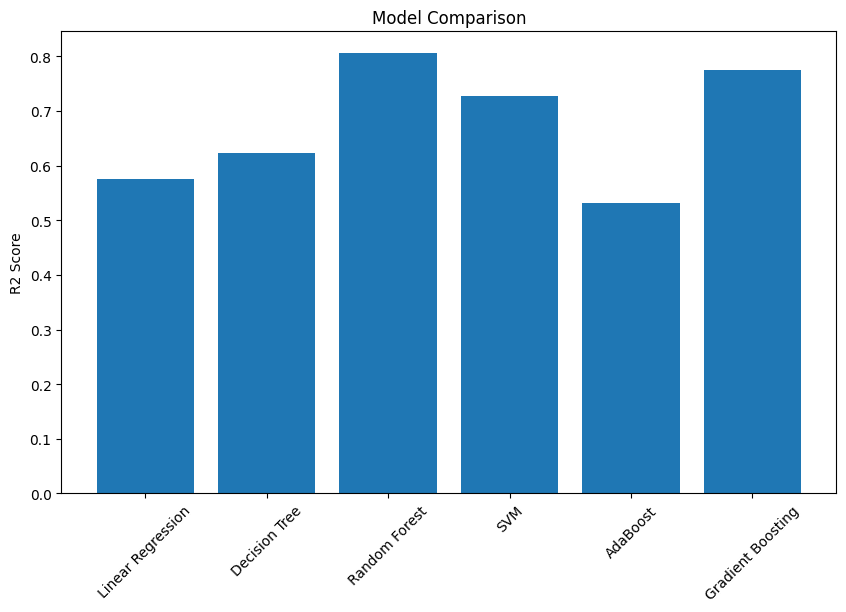

In [14]:
# Model Comparison Graph
plt.figure(figsize=(10,6))

models = results['Model']
scores = results['R2 Score']

plt.bar(models, scores)
plt.xticks(rotation=45)
plt.ylabel("R2 Score")
plt.title("Model Comparison")

plt.show()

## Model Comparison Report

Multiple machine learning models were implemented to predict housing prices.

Linear Regression provided baseline performance.
Decision Tree showed instability due to overfitting.
Random Forest improved accuracy significantly by combining multiple trees.
SVM performed moderately but required feature scaling.
Boosting algorithms further enhanced performance by reducing errors sequentially.

After hyperparameter tuning, Random Forest achieved the best performance with the highest R2 score.

Therefore, ensemble methods proved more effective than single models for housing price prediction.